Loading data...
Adding regioncode...
Missing regioncode after merge: 0
Preparing nitrogen indicators...
Computing SNMI...
SNMI missing values: 240
Creating figure...


OSError: [Errno 28] No space left on device: 'Y:\\Home\\goyal\\collaboration\\2025\\rohini\\SNMI\\FIG\\Figure2_Nharvest_Napplied_NUE_SNMI.png'

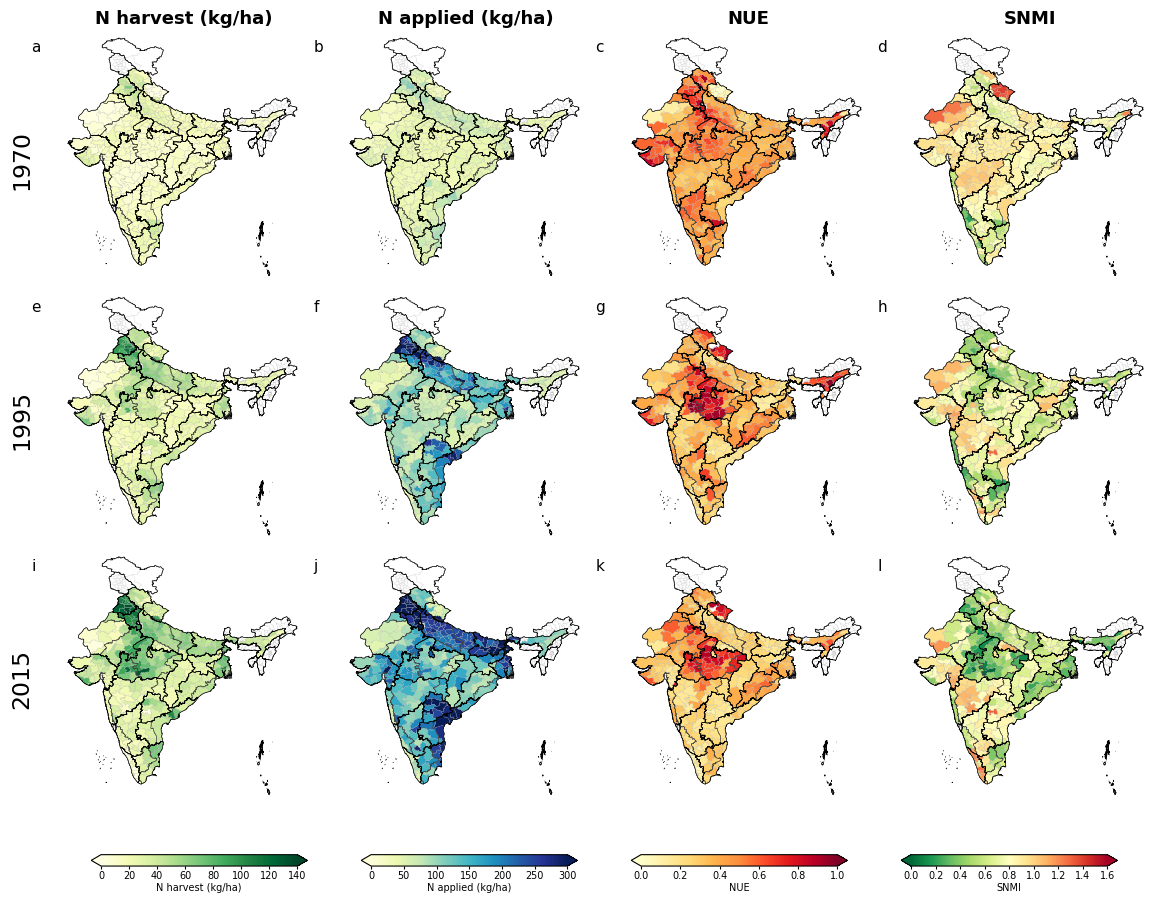

In [3]:
# -*- coding: utf-8 -*-
"""
Figure 2: Spatial patterns of N harvest, N applied, NUE and SNMI
Years: 1970, 1995, 2015

Standalone from-scratch script.
"""

# ============================================================
# 0. IMPORTS
# ============================================================

import os
import string
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

warnings.filterwarnings("ignore")


# ============================================================
# 1. USER SETTINGS
# ============================================================

NSURPLUS_FILE = r"C:\collaboration\2025\rohini\SNMI\snmi work\data/nsurplus_district_comp.csv"

DISTRICT_SHP = r"Y:\Home\goyal\latest_backup_lab_pc\shekhar\climate  extreames\district_shape_1966_clim_zone\india_1966_clim_zone.shp"

AGROCLIM_SHP = r"Y:\Home\goyal\latest_backup_lab_pc\shekhar\climate  extreames\data\AGRO_CLIMATE_SHP\Agroclimatic_regions.shp"

STATE_BOUNDARY_SHP = r"Y:\Home\goyal\latest_backup_lab_pc\shekhar\paper3_goyal\final_submission\nsurplus_paper\code\ns_paper\shape_file\India-State-and-Country-Shapefile-Updated-Jan-2020-master (1)\India-State-and-Country-Shapefile-Updated-Jan-2020-master\India_State_Boundary.shp"

SAVE_DIR = r"Y:\Home\goyal\collaboration\2025\rohini\SNMI\FIG"
os.makedirs(SAVE_DIR, exist_ok=True)

OUT_PNG = os.path.join(SAVE_DIR, "Figure2_Nharvest_Napplied_NUE_SNMI.png")
OUT_PDF = os.path.join(SAVE_DIR, "Figure2_Nharvest_Napplied_NUE_SNMI.pdf")


# ============================================================
# 2. HELPER FUNCTIONS
# ============================================================

def clean_name(x):
    if pd.isna(x):
        return np.nan
    return (
        str(x)
        .strip()
        .replace("&", "and")
        .replace("  ", " ")
        .title()
    )


def standardize_columns(df):
    df = df.copy()
    df.columns = df.columns.str.strip()
    return df


def get_nue_star(nue):
    """
    NUE* calculation for SNMI.

    Optimal NUE range: 0.5 to 0.9.
    """
    if pd.isna(nue):
        return np.nan

    if 0.5 <= nue <= 0.9:
        return 1.0

    if nue < 0.5:
        return nue / 0.5

    return max(0, 1 - ((nue - 0.9) / 0.1))


def get_nyield_star_dynamic(nyield, regioncode, nyield_refs):
    nyield_ref = nyield_refs.get(regioncode, np.nan)

    if pd.isna(nyield) or pd.isna(nyield_ref) or nyield_ref == 0:
        return np.nan

    if nyield <= nyield_ref:
        return nyield / nyield_ref

    return 1.0


# ============================================================
# 3. LOAD DATA
# ============================================================

print("Loading data...")

fert = pd.read_csv(NSURPLUS_FILE)
fert = standardize_columns(fert)

gdf = gpd.read_file(DISTRICT_SHP).to_crs(epsg=4326)
agroclim_gdf = gpd.read_file(AGROCLIM_SHP).to_crs(epsg=4326)
state_boundary_gdf = gpd.read_file(STATE_BOUNDARY_SHP).to_crs(epsg=4326)

gdf = standardize_columns(gdf)
agroclim_gdf = standardize_columns(agroclim_gdf)
state_boundary_gdf = standardize_columns(state_boundary_gdf)


# ============================================================
# 4. PREPARE SHAPEFILE COLUMNS
# ============================================================

rename_shape_cols = {
    "State": "State Name",
    "STATE": "State Name",
    "State_Name": "State Name",
    "ST_NM": "State Name",
    "Parent_dis": "Dist Name",
    "DISTRICT": "Dist Name",
    "District": "Dist Name",
    "DIST_NAME": "Dist Name",
    "Dist_Name": "Dist Name",
}

gdf = gdf.rename(
    columns={k: v for k, v in rename_shape_cols.items() if k in gdf.columns}
)

if "State Name" not in gdf.columns or "Dist Name" not in gdf.columns:
    raise ValueError(
        "District shapefile must contain State Name and Dist Name columns.\n"
        f"Available columns are:\n{list(gdf.columns)}"
    )

gdf["State Name"] = gdf["State Name"].apply(clean_name)
gdf["Dist Name"] = gdf["Dist Name"].apply(clean_name)


# ============================================================
# 5. PREPARE N-SURPLUS DATA
# ============================================================

fert["State Name"] = fert["State Name"].apply(clean_name)
fert["Dist Name"] = fert["Dist Name"].apply(clean_name)
fert["Year"] = pd.to_numeric(fert["Year"], errors="coerce").astype("Int64")

# Convert numeric columns safely
for col in fert.columns:
    if col not in ["State Name", "Dist Name"]:
        try:
            fert[col] = pd.to_numeric(fert[col], errors="coerce")
        except Exception:
            pass


# ============================================================
# 6. ADD regioncode FROM SHAPEFILE
# ============================================================

print("Adding regioncode...")

if "regioncode" not in fert.columns:

    possible_region_cols = [
        "regioncode",
        "Regioncode",
        "REGIONCODE",
        "region_code",
        "REGION_CODE",
        "clim_code",
        "CLIM_CODE"
    ]

    region_col = None
    for c in possible_region_cols:
        if c in gdf.columns:
            region_col = c
            break

    if region_col is None:
        raise ValueError(
            "No regioncode column found in the district shapefile.\n"
            f"Available shapefile columns are:\n{list(gdf.columns)}"
        )

    region_lookup = (
        gdf[["State Name", "Dist Name", region_col]]
        .drop_duplicates()
        .rename(columns={region_col: "regioncode"})
    )

    fert = fert.merge(
        region_lookup,
        on=["State Name", "Dist Name"],
        how="left"
    )

missing_region = fert["regioncode"].isna().sum()
print("Missing regioncode after merge:", missing_region)

if missing_region > 0:
    missing_preview = (
        fert.loc[fert["regioncode"].isna(), ["State Name", "Dist Name"]]
        .drop_duplicates()
        .head(30)
    )
    print("\nFirst unmatched districts:")
    print(missing_preview)


# ============================================================
# 7. CALCULATE N HARVEST, N INPUT, NUE
# ============================================================

print("Preparing nitrogen indicators...")

budget_columns = [f"N_budjet_{i}_kg_ha" for i in range(1, 13)]
available_budget_cols = [c for c in budget_columns if c in fert.columns]

if len(available_budget_cols) == 0:
    raise ValueError("No N_budjet_*_kg_ha columns found.")

fert["N_budget_mean_kg_ha"] = fert[available_budget_cols].mean(axis=1)

required_removal_cols = ["n_removal_kg_ha", "n_removal_kg_ha_fao"]
missing_removal = [c for c in required_removal_cols if c not in fert.columns]

if missing_removal:
    raise ValueError(f"Missing N removal columns: {missing_removal}")

fert["n_removed_mean"] = fert[required_removal_cols].mean(axis=1)

if "N_total_input_kg/ha_mean" not in fert.columns:

    input_component_cols = [
        "Fertilizer mean",
        "Manure_mean",
        "BNF_mean",
        "Nitrogen Deposition(kgN/ha)"
    ]

    input_component_cols = [c for c in input_component_cols if c in fert.columns]

    if len(input_component_cols) == 0:
        raise ValueError(
            "N_total_input_kg/ha_mean not found and no input components found."
        )

    fert["N_total_input_kg/ha_mean"] = fert[input_component_cols].sum(axis=1)

if "NUE_mean" not in fert.columns:
    fert["NUE_mean"] = fert["n_removed_mean"] / fert["N_total_input_kg/ha_mean"]

fert.loc[fert["NUE_mean"] > 1, "NUE_mean"] = np.nan

metrics_to_replace = [
    "N_budget_mean_kg_ha",
    "N_total_input_kg/ha_mean",
    "n_removed_mean"
]

state_year_means = (
    fert.groupby(["State Name", "Year"])[metrics_to_replace]
    .transform("mean")
)

for metric in metrics_to_replace:
    fert.loc[fert["NUE_mean"].isna(), metric] = state_year_means[metric]


# ============================================================
# 8. COMPUTE SNMI FROM SCRATCH
# ============================================================

print("Computing SNMI...")

clim_zone_data_copy = fert.copy()

if "NYield_max" in clim_zone_data_copy.columns:
    clim_zone_data_copy = clim_zone_data_copy.drop(columns=["NYield_max"])

clim_zone_data_copy["NYield"] = clim_zone_data_copy[
    ["n_removal_kg_ha", "n_removal_kg_ha_fao"]
].mean(axis=1)

max_yield_district = (
    clim_zone_data_copy
    .groupby(["State Name", "Dist Name"], as_index=False)["NYield"]
    .max()
    .rename(columns={"NYield": "NYield_max"})
)

clim_zone_data_copy = clim_zone_data_copy.merge(
    max_yield_district,
    on=["State Name", "Dist Name"],
    how="left"
)

nyield_refs = (
    clim_zone_data_copy
    .dropna(subset=["regioncode", "NYield_max"])
    .groupby("regioncode")["NYield_max"]
    .quantile(0.9)
    .to_dict()
)

clim_zone_data_copy["NYield_star"] = clim_zone_data_copy.apply(
    lambda row: get_nyield_star_dynamic(
        row["NYield"],
        row["regioncode"],
        nyield_refs
    ),
    axis=1
)

clim_zone_data_copy["NUE_star"] = clim_zone_data_copy["NUE_mean"].apply(get_nue_star)

clim_zone_data_copy["SNMI"] = np.sqrt(
    (1 - clim_zone_data_copy["NYield_star"]) ** 2 +
    (1 - clim_zone_data_copy["NUE_star"]) ** 2
)

fert = fert.drop(
    columns=["SNMI", "NYield_star", "NUE_star"],
    errors="ignore"
)

fert = fert.merge(
    clim_zone_data_copy[
        ["State Name", "Dist Name", "Year", "SNMI", "NYield_star", "NUE_star"]
    ],
    on=["State Name", "Dist Name", "Year"],
    how="left"
)

print("SNMI missing values:", fert["SNMI"].isna().sum())


# ============================================================
# 9. FIGURE SETTINGS
# ============================================================

metrics = {
    "n_removed_mean": {
        "title": "N harvest (kg/ha)",
        "cmap": "YlGn",
        "vmin": 0,
        "vmax": 140,
        "ticks": [0, 20, 40, 60, 80, 100, 120, 140],
    },
    "N_total_input_kg/ha_mean": {
        "title": "N applied (kg/ha)",
        "cmap": "YlGnBu",
        "vmin": 0,
        "vmax": 300,
        "ticks": [0, 50, 100, 150, 200, 250, 300],
    },
    "NUE_mean": {
        "title": "NUE",
        "cmap": "YlOrRd",
        "vmin": 0,
        "vmax": 1,
        "ticks": [0, 0.2, 0.4, 0.6, 0.8, 1.0],
    },
    "SNMI": {
        "title": "SNMI",
        "cmap": "RdYlGn_r",
        "vmin": 0,
        "vmax": 1.6,
        "ticks": [0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6],
    },
}

selected_time_periods = {
    "1970": (1969, 1971),
    "1995": (1994, 1996),
    "2015": (2014, 2016),
}

panel_letters = list(string.ascii_lowercase[:12])


# ============================================================
# 10. CREATE FIGURE
# ============================================================

print("Creating figure...")

fig, axes = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(12, 9.5)
)

plt.subplots_adjust(
    left=0.055,
    right=0.985,
    top=0.93,
    bottom=0.12,
    wspace=0.045,
    hspace=0.035
)

smap_dict = {}
letter_idx = 0

for row_idx, (year_label, (start_year, end_year)) in enumerate(selected_time_periods.items()):

    fert_period = fert[
        (fert["Year"] >= start_year) &
        (fert["Year"] <= end_year)
    ].copy()

    fert_mean = (
        fert_period
        .groupby(["State Name", "Dist Name"], as_index=False)
        .mean(numeric_only=True)
    )

    merged = gdf.merge(
        fert_mean,
        on=["State Name", "Dist Name"],
        how="left"
    )

    for col_idx, (metric, cfg) in enumerate(metrics.items()):

        ax = axes[row_idx, col_idx]

        cmap = plt.get_cmap(cfg["cmap"])
        norm = mcolors.Normalize(vmin=cfg["vmin"], vmax=cfg["vmax"])

        merged.plot(
            column=metric,
            ax=ax,
            cmap=cmap,
            norm=norm,
            linewidth=0.0,
            edgecolor="none",
            missing_kwds={"color": "white"}
        )

        gdf.boundary.plot(
            ax=ax,
            color="0.65",
            linewidth=0.12,
            alpha=0.6
        )

        agroclim_gdf.boundary.plot(
            ax=ax,
            color="0.25",
            linewidth=0.35,
            alpha=0.9
        )

        state_boundary_gdf.boundary.plot(
            ax=ax,
            color="black",
            linewidth=0.45,
            alpha=0.9
        )

        ax.set_xlim(67.5, 98.5)
        ax.set_ylim(5.5, 37.5)
        ax.set_aspect("equal")
        ax.axis("off")

        if row_idx == 0:
            ax.set_title(
                cfg["title"],
                fontsize=13,
                fontweight="bold",
                pad=8
            )

        if col_idx == 0:
            ax.text(
                -0.17,
                0.50,
                year_label,
                transform=ax.transAxes,
                rotation=90,
                fontsize=17,
                va="center",
                ha="center"
            )

        ax.text(
            -0.13,
            0.98,
            panel_letters[letter_idx],
            transform=ax.transAxes,
            fontsize=11,
            va="top",
            ha="left"
        )

        letter_idx += 1

        if row_idx == 0:
            smap_dict[metric] = cm.ScalarMappable(cmap=cmap, norm=norm)
            smap_dict[metric].set_array([])


# ============================================================
# 11. COLORBARS
# ============================================================

cbar_positions = {
    "n_removed_mean": [0.09, 0.055, 0.18, 0.012],
    "N_total_input_kg/ha_mean": [0.315, 0.055, 0.18, 0.012],
    "NUE_mean": [0.54, 0.055, 0.18, 0.012],
    "SNMI": [0.765, 0.055, 0.18, 0.012],
}

for metric, pos in cbar_positions.items():

    cfg = metrics[metric]
    cax = fig.add_axes(pos)

    cbar = fig.colorbar(
        smap_dict[metric],
        cax=cax,
        orientation="horizontal",
        extend="both"
    )

    cbar.set_ticks(cfg["ticks"])
    cbar.ax.tick_params(labelsize=7, length=2, pad=1)
    cbar.set_label(cfg["title"], fontsize=7, labelpad=2)


# ============================================================
# 12. SAVE OUTPUT
# ============================================================

fig.savefig(
    OUT_PNG,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    OUT_PDF,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Figure saved:")
print(OUT_PNG)
print(OUT_PDF)

Loading data...
Rows without regioncode: 0
Calculating N indicators...
Calculating SNMI...
Saved calculated SNMI data: C:\collaboration\2025\rohini\SNMI\snmi work\data\fig2_output\Figure2_SNMI_calculated_data.csv
Creating figure...


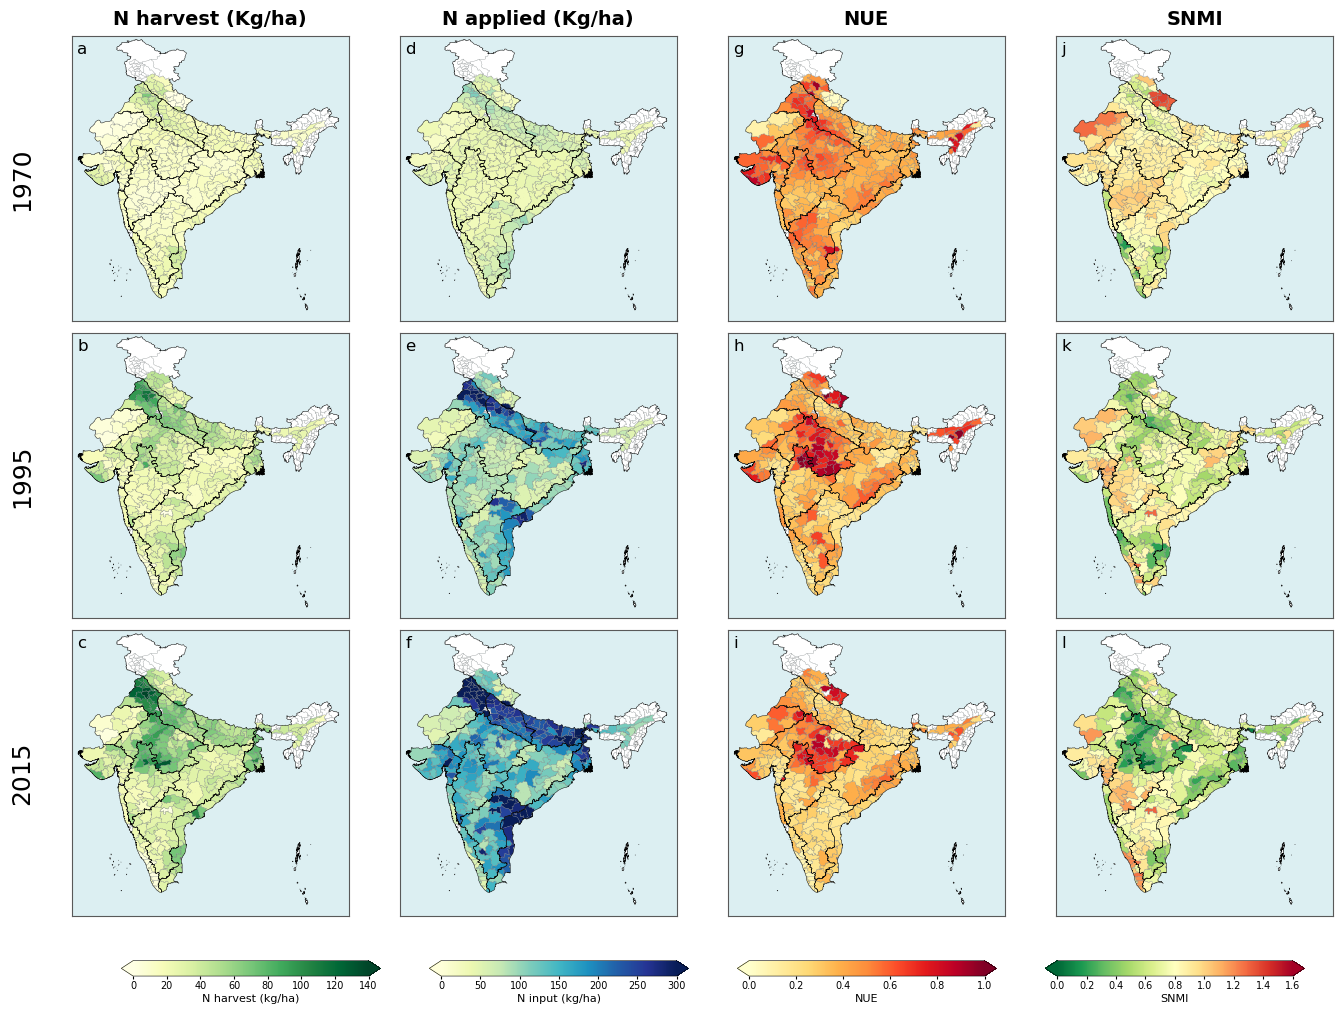

Saved figure: C:\collaboration\2025\rohini\SNMI\snmi work\data\fig2_output\Figure2_Nharvest_Ninput_NUE_SNMI.png
Done.


In [6]:
# -*- coding: utf-8 -*-
"""
Figure 2: Spatial patterns of N harvest, N applied, NUE and SNMI
Author: Shekhar Goyal

This script:
1. Loads district-level nitrogen surplus data
2. Loads India district shapefile and agroclimatic region shapefile
3. Computes:
   - N harvest
   - N applied
   - NUE
   - NYield*
   - NUE*
   - SNMI
4. Aggregates values for 1970, 1995 and 2015 windows
5. Produces publication-ready 3 x 4 panel map figure
"""

# ============================================================
# 0. IMPORT LIBRARIES
# ============================================================

import os
import string
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

warnings.filterwarnings("ignore")


# ============================================================
# 1. USER SETTINGS
# ============================================================

NSURPLUS_CSV = r"C:\collaboration\2025\rohini\SNMI\snmi work\data\nsurplus_district_comp.csv"

DISTRICT_SHP = r"Y:\Home\goyal\latest_backup_lab_pc\shekhar\climate  extreames\district_shape_1966_clim_zone\india_1966_clim_zone.shp"

AGROCLIM_SHP = r"Y:\Home\goyal\latest_backup_lab_pc\shekhar\climate  extreames\data\AGRO_CLIMATE_SHP\Agroclimatic_regions.shp"

SAVE_DIR = r"C:\collaboration\2025\rohini\SNMI\snmi work\data\fig2_output"
os.makedirs(SAVE_DIR, exist_ok=True)

OUT_FIG = os.path.join(SAVE_DIR, "Figure2_Nharvest_Ninput_NUE_SNMI.png")
OUT_DATA = os.path.join(SAVE_DIR, "Figure2_SNMI_calculated_data.csv")

DPI = 600


# ============================================================
# 2. HELPER FUNCTIONS
# ============================================================

def clean_name(x):
    """Standardize district/state names for merging."""
    if pd.isna(x):
        return np.nan
    return (
        str(x)
        .strip()
        .lower()
        .replace("&", "and")
        .replace(".", "")
        .replace(",", "")
        .replace("  ", " ")
    )


def get_nue_star(nue, lower=0.50, upper=0.90):
    """
    Compute NUE*.

    NUE is considered optimal between lower and upper.
    Below lower: NUE* increases linearly from 0 to 1.
    Above upper: NUE* decreases linearly from 1 to 0.
    """
    if pd.isna(nue):
        return np.nan

    if nue < 0:
        return np.nan

    if nue < lower:
        return nue / lower

    if lower <= nue <= upper:
        return 1.0

    if nue > upper and nue <= 1:
        return (1 - nue) / (1 - upper)

    return np.nan


def get_nyield_star(nyield, regioncode, nyield_refs):
    """Compute climate-zone-specific NYield*."""
    nyield_ref = nyield_refs.get(regioncode, np.nan)

    if pd.isna(nyield) or pd.isna(nyield_ref) or nyield_ref == 0:
        return np.nan

    if nyield <= nyield_ref:
        return nyield / nyield_ref

    return 1.0


def add_panel_label(ax, label):
    ax.text(
        0.02, 0.98, label,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=12,
        fontweight="normal",
        color="black"
    )


# ============================================================
# 3. LOAD DATA
# ============================================================

print("Loading data...")

n_data = pd.read_csv(NSURPLUS_CSV)
gdf = gpd.read_file(DISTRICT_SHP).to_crs(epsg=4326)
agroclim_gdf = gpd.read_file(AGROCLIM_SHP).to_crs(epsg=4326)

# Rename shapefile columns
rename_shape = {
    "State": "State Name",
    "Parent_dis": "Dist Name",
    "District": "Dist Name",
    "DISTRICT": "Dist Name",
    "STATE": "State Name"
}

gdf = gdf.rename(columns={k: v for k, v in rename_shape.items() if k in gdf.columns})

if "State Name" not in gdf.columns or "Dist Name" not in gdf.columns:
    raise ValueError("District shapefile must contain State and District columns.")

if "regioncode" not in gdf.columns:
    raise ValueError("District shapefile must contain 'regioncode' for climate-zone SNMI calculation.")

# Clean names
for df in [n_data, gdf]:
    df["state_clean"] = df["State Name"].apply(clean_name)
    df["dist_clean"] = df["Dist Name"].apply(clean_name)

n_data["Year"] = pd.to_numeric(n_data["Year"], errors="coerce")


# ============================================================
# 4. ATTACH REGIONCODE TO N DATA
# ============================================================

region_lookup = gdf[
    ["state_clean", "dist_clean", "regioncode"]
].drop_duplicates()

n_data = n_data.merge(
    region_lookup,
    on=["state_clean", "dist_clean"],
    how="left"
)

print("Rows without regioncode:", n_data["regioncode"].isna().sum())


# ============================================================
# 5. CALCULATE N COMPONENTS
# ============================================================

print("Calculating N indicators...")

budget_cols = [
    f"N_budjet_{i}_kg_ha" for i in range(1, 13)
    if f"N_budjet_{i}_kg_ha" in n_data.columns
]

nue_cols = [
    f"NUE_{i}" for i in range(1, 13)
    if f"NUE_{i}" in n_data.columns
]

if len(budget_cols) == 0:
    raise ValueError("No N budget columns found.")

if len(nue_cols) == 0 and "NUE_mean" not in n_data.columns:
    raise ValueError("No NUE columns found.")

# N surplus / budget mean
n_data["N_budget_mean_kg_ha"] = n_data[budget_cols].mean(axis=1)

# N harvest
n_data["N_harvest_kg_ha"] = n_data[
    ["n_removal_kg_ha", "n_removal_kg_ha_fao"]
].mean(axis=1)

# N applied / total input
if "N_total_input_kg/ha_mean" not in n_data.columns:
    if "N_total_input_kg/ha" in n_data.columns:
        n_data["N_total_input_kg/ha_mean"] = n_data["N_total_input_kg/ha"]
    else:
        input_parts = [
            c for c in [
                "Fertilizer mean",
                "Manure_mean",
                "BNF_mean",
                "Nitrogen Deposition(kgN/ha)"
            ]
            if c in n_data.columns
        ]

        n_data["N_total_input_kg/ha_mean"] = n_data[input_parts].sum(axis=1)

# NUE
if "NUE_mean" not in n_data.columns:
    n_data["NUE_mean"] = n_data[nue_cols].mean(axis=1)

# Remove unrealistic NUE
n_data.loc[(n_data["NUE_mean"] < 0) | (n_data["NUE_mean"] > 1), "NUE_mean"] = np.nan

# Fill dependent N metrics where NUE is missing using state-year mean
replace_cols = [
    "N_budget_mean_kg_ha",
    "N_total_input_kg/ha_mean",
    "N_harvest_kg_ha"
]

state_year_means = (
    n_data.groupby(["State Name", "Year"])[replace_cols]
    .transform("mean")
)

for col in replace_cols:
    n_data.loc[n_data["NUE_mean"].isna(), col] = state_year_means[col]


# ============================================================
# 6. CALCULATE SNMI
# ============================================================

print("Calculating SNMI...")

n_data["NYield"] = n_data["N_harvest_kg_ha"]

# District maximum NYield
district_max = (
    n_data.groupby(["State Name", "Dist Name"], as_index=False)["NYield"]
    .max()
    .rename(columns={"NYield": "NYield_max"})
)

n_data = n_data.merge(
    district_max,
    on=["State Name", "Dist Name"],
    how="left"
)

# Climate-zone-specific 90th percentile reference yield
nyield_refs = (
    n_data.dropna(subset=["regioncode", "NYield_max"])
    .groupby("regioncode")["NYield_max"]
    .quantile(0.90)
    .to_dict()
)

n_data["NYield_star"] = n_data.apply(
    lambda row: get_nyield_star(
        row["NYield"],
        row["regioncode"],
        nyield_refs
    ),
    axis=1
)

n_data["NUE_star"] = n_data["NUE_mean"].apply(get_nue_star)

n_data["SNMI"] = np.sqrt(
    (1 - n_data["NYield_star"]) ** 2 +
    (1 - n_data["NUE_star"]) ** 2
)

n_data.to_csv(OUT_DATA, index=False)
print(f"Saved calculated SNMI data: {OUT_DATA}")


# ============================================================
# 7. FIGURE SETTINGS
# ============================================================

metrics = {
    "N_harvest_kg_ha": {
        "title": "N harvest (Kg/ha)",
        "cbar": "N harvest (kg/ha)",
        "cmap": "YlGn",
        "vmin": 0,
        "vmax": 140,
        "ticks": [0, 20, 40, 60, 80, 100, 120, 140]
    },
    "N_total_input_kg/ha_mean": {
        "title": "N applied (Kg/ha)",
        "cbar": "N input (kg/ha)",
        "cmap": "YlGnBu",
        "vmin": 0,
        "vmax": 300,
        "ticks": [0, 50, 100, 150, 200, 250, 300]
    },
    "NUE_mean": {
        "title": "NUE",
        "cbar": "NUE",
        "cmap": "YlOrRd",
        "vmin": 0,
        "vmax": 1,
        "ticks": [0, 0.2, 0.4, 0.6, 0.8, 1.0]
    },
    "SNMI": {
        "title": "SNMI",
        "cbar": "SNMI",
        "cmap": "RdYlGn_r",
        "vmin": 0,
        "vmax": 1.6,
        "ticks": [0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]
    }
}

selected_periods = {
    "1970": (1969, 1971),
    "1995": (1994, 1996),
    "2015": (2014, 2016)
}

letters = list(string.ascii_lowercase)


# ============================================================
# 8. CREATE FIGURE
# ============================================================

print("Creating figure...")

fig, axes = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(14, 11),
    constrained_layout=False
)

fig.patch.set_facecolor("white")

smap_dict = {}

for row_idx, (period_label, (start_year, end_year)) in enumerate(selected_periods.items()):

    period_data = n_data[
        (n_data["Year"] >= start_year) &
        (n_data["Year"] <= end_year)
    ].copy()

    period_mean = (
        period_data
        .groupby(["state_clean", "dist_clean"], as_index=False)
        .mean(numeric_only=True)
    )

    merged = gdf.merge(
        period_mean,
        on=["state_clean", "dist_clean"],
        how="left"
    )

    for col_idx, (metric, cfg) in enumerate(metrics.items()):

        ax = axes[row_idx, col_idx]

        cmap = plt.get_cmap(cfg["cmap"])
        norm = mcolors.Normalize(vmin=cfg["vmin"], vmax=cfg["vmax"])

        ax.set_facecolor("#dceff2")

        merged.plot(
            column=metric,
            ax=ax,
            cmap=cmap,
            norm=norm,
            edgecolor="none",
            linewidth=0.0,
            missing_kwds={"color": "white"}
        )

        # District boundary
        gdf.boundary.plot(
            ax=ax,
            color="0.45",
            linewidth=0.15,
            alpha=0.65
        )

        # Agroclimatic boundary
        agroclim_gdf.boundary.plot(
            ax=ax,
            color="black",
            linewidth=0.35,
            alpha=0.85
        )

        ax.set_xlim(67.5, 98.5)
        ax.set_ylim(5.5, 37.5)
        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
            spine.set_color("0.35")

        # Panel label
        panel_number = col_idx * 3 + row_idx
        add_panel_label(ax, letters[panel_number])

        # Column title
        if row_idx == 0:
            ax.set_title(
                cfg["title"],
                fontsize=14,
                fontweight="bold",
                pad=8
            )

        # Row year label
        if col_idx == 0:
            ax.text(
                -0.18, 0.50,
                period_label,
                transform=ax.transAxes,
                rotation=90,
                fontsize=18,
                fontweight="normal",
                ha="center",
                va="center"
            )

        if row_idx == 0:
            smap_dict[metric] = cm.ScalarMappable(
                cmap=cmap,
                norm=norm
            )
            smap_dict[metric].set_array([])


# ============================================================
# 9. ADD COLORBARS
# ============================================================

plt.subplots_adjust(
    left=0.06,
    right=0.98,
    top=0.93,
    bottom=0.13,
    wspace=0.08,
    hspace=0.04
)

cbar_positions = {
    "N_harvest_kg_ha": [0.105, 0.075, 0.185, 0.014],
    "N_total_input_kg/ha_mean": [0.325, 0.075, 0.185, 0.014],
    "NUE_mean": [0.545, 0.075, 0.185, 0.014],
    "SNMI": [0.765, 0.075, 0.185, 0.014],
}

for metric, pos in cbar_positions.items():

    cfg = metrics[metric]
    cax = fig.add_axes(pos)

    cbar = fig.colorbar(
        smap_dict[metric],
        cax=cax,
        orientation="horizontal",
        extend="both"
    )

    cbar.set_label(
        cfg["cbar"],
        fontsize=8,
        labelpad=2
    )

    cbar.set_ticks(cfg["ticks"])
    cbar.ax.tick_params(
        labelsize=7,
        length=2,
        pad=1
    )

    cbar.outline.set_linewidth(0.4)


# ============================================================
# 10. SAVE FIGURE
# ============================================================

plt.savefig(
    OUT_FIG,
    dpi=DPI,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(f"Saved figure: {OUT_FIG}")
print("Done.")